## Demo: ResNet-18 leaf trait predictions on held-out test leaves

Loads the checkpoint saved in `retraining.ipynb` (`checkpoints/resnet18_leaf_traits.pt`), reproduces the exact same leaf-grouped test split used to train it, and shows real leaf images side by side with actual vs. predicted FMC/chlorophyll/nitrogen/weight — on leaves the model never saw during training.

Leaf images below are a false-color preview built from bands 3/2/1 (Red/Green/Blue, per the paper's stated band order) — not the raw model input, just for human viewing. The faint rainbow fringe at leaf edges is a real artifact of the source data: each band was captured as a separate exposure, so edges aren't perfectly pixel-aligned across bands.

In [1]:
import re
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error
from torchvision.models import resnet18

DATA_DIR = Path("../data") if Path("../data/DATASET").exists() else Path("data")
ROOT = DATA_DIR / "DATASET"
SPECIES = ["Avocado", "Olive", "Vineyard"]
CHECKPOINT_PATH = Path("checkpoints/resnet18_leaf_traits.pt")

/Users/im/repos/poc-rbr-2026/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load the trained model

In [2]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
TRAITS = checkpoint["traits"]
TRAIT_UNITS = checkpoint["trait_units"]
IMG_SIZE = checkpoint["img_size"]
y_mean = checkpoint["y_mean"]
y_std = checkpoint["y_std"]

model = resnet18(weights=None)
old_conv = model.conv1
model.conv1 = nn.Conv2d(checkpoint["in_channels"], old_conv.out_channels,
                         kernel_size=old_conv.kernel_size, stride=old_conv.stride,
                         padding=old_conv.padding, bias=False)
model.fc = nn.Linear(model.fc.in_features, len(TRAITS))
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"loaded model predicting {TRAITS} ({[TRAIT_UNITS[t] for t in TRAITS]})")

loaded model predicting ['fmc', 'chlorophyll', 'nitrogen', 'weight'] (['%', 'SPAD', 'mg/g', 'g'])


### Reproduce the exact same test split

The checkpoint only stores weights, not which leaves were held out — so the split is rebuilt here with identical logic and the same `random_state=0` as `retraining.ipynb`. This reproduces the same partition as long as the dataset directory hasn't changed, which it hasn't.

In [3]:
PATTERN = re.compile(r"leaf(\d+)d(\d+)_(\d+)\.tif")

def load_labels(species: str) -> dict:
    import scipy.io as sio
    s = species.lower()
    fmc = sio.loadmat(ROOT / species / f"FMC_{s}.mat")[f"FMC_d_{s}"]
    chl = sio.loadmat(ROOT / species / f"Chlorophyll_{s}.mat")[f"chlorophyll_{s}"]
    nit = sio.loadmat(ROOT / species / f"Nitrogen_{s}.mat")[f"nitrogen_{s}"]
    weight_file = ROOT / species / f"Weight_{species}.mat"
    if not weight_file.exists():
        weight_file = ROOT / species / f"Weight_{s}.mat"
    wgt = sio.loadmat(weight_file)[f"weight_{s}"]
    return {"fmc": fmc, "chlorophyll": chl, "nitrogen": nit, "weight": wgt}

labels_by_species = {sp: load_labels(sp) for sp in SPECIES}

samples = []
for sp in SPECIES:
    img_dir = ROOT / sp / "Multispectral Images"
    by_key = {}
    for p in img_dir.glob("*.tif"):
        m = PATTERN.match(p.name)
        if not m:
            continue
        leaf, stage, band = int(m.group(1)), int(m.group(2)), int(m.group(3))
        by_key.setdefault((leaf, stage), {})[band] = p
    for (leaf, stage), bands in by_key.items():
        if set(bands) != {1, 2, 3, 4, 5}:
            continue
        labels = labels_by_species[sp]
        if leaf >= labels["fmc"].shape[0]:
            continue
        target = np.array([labels[t][leaf, stage] for t in TRAITS], dtype=np.float32)
        samples.append({"species": sp, "leaf": leaf, "stage": stage,
                         "band_paths": [bands[b] for b in range(1, 6)], "target": target})

groups = np.array([f"{s['species']}_{s['leaf']}" for s in samples])
all_idx = np.arange(len(samples))

TEST_SIZE, VAL_SIZE = 0.15, 0.15
test_splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=0)
trainval_idx, test_idx = next(test_splitter.split(all_idx, groups=groups))

print(f"{len(samples)} total samples, {len(test_idx)} in the reproduced test split")

1595 total samples, 240 in the reproduced test split


### Run inference on the full test set

In [4]:
def load_model_input(band_paths: list[Path]) -> np.ndarray:
    bands = [np.array(Image.open(p).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR), dtype=np.float32)
             for p in band_paths]
    return np.stack(bands, axis=0) / 65535.0

X_test = np.stack([load_model_input(samples[i]["band_paths"]) for i in test_idx])
y_test = np.stack([samples[i]["target"] for i in test_idx])

with torch.no_grad():
    preds_z = model(torch.from_numpy(X_test)).numpy()
test_preds = preds_z * y_std + y_mean

print(f"{'trait':12s} {'R2':>8s} {'MAE':>10s}")
for i, t in enumerate(TRAITS):
    r2 = r2_score(y_test[:, i], test_preds[:, i])
    mae = mean_absolute_error(y_test[:, i], test_preds[:, i])
    print(f"{t:12s} {r2:8.3f} {mae:10.3f}")

test_idx_to_pos = {idx: pos for pos, idx in enumerate(test_idx)}

trait              R2        MAE
fmc             0.806     23.379
chlorophyll     0.761      8.795
nitrogen        0.836      2.082
weight          0.808      0.288


### Visual demo: one held-out leaf per species, all 5 dehydration stages

Each row is a single leaf the model never trained on, followed fresh (d0) through fully desiccated (d4).

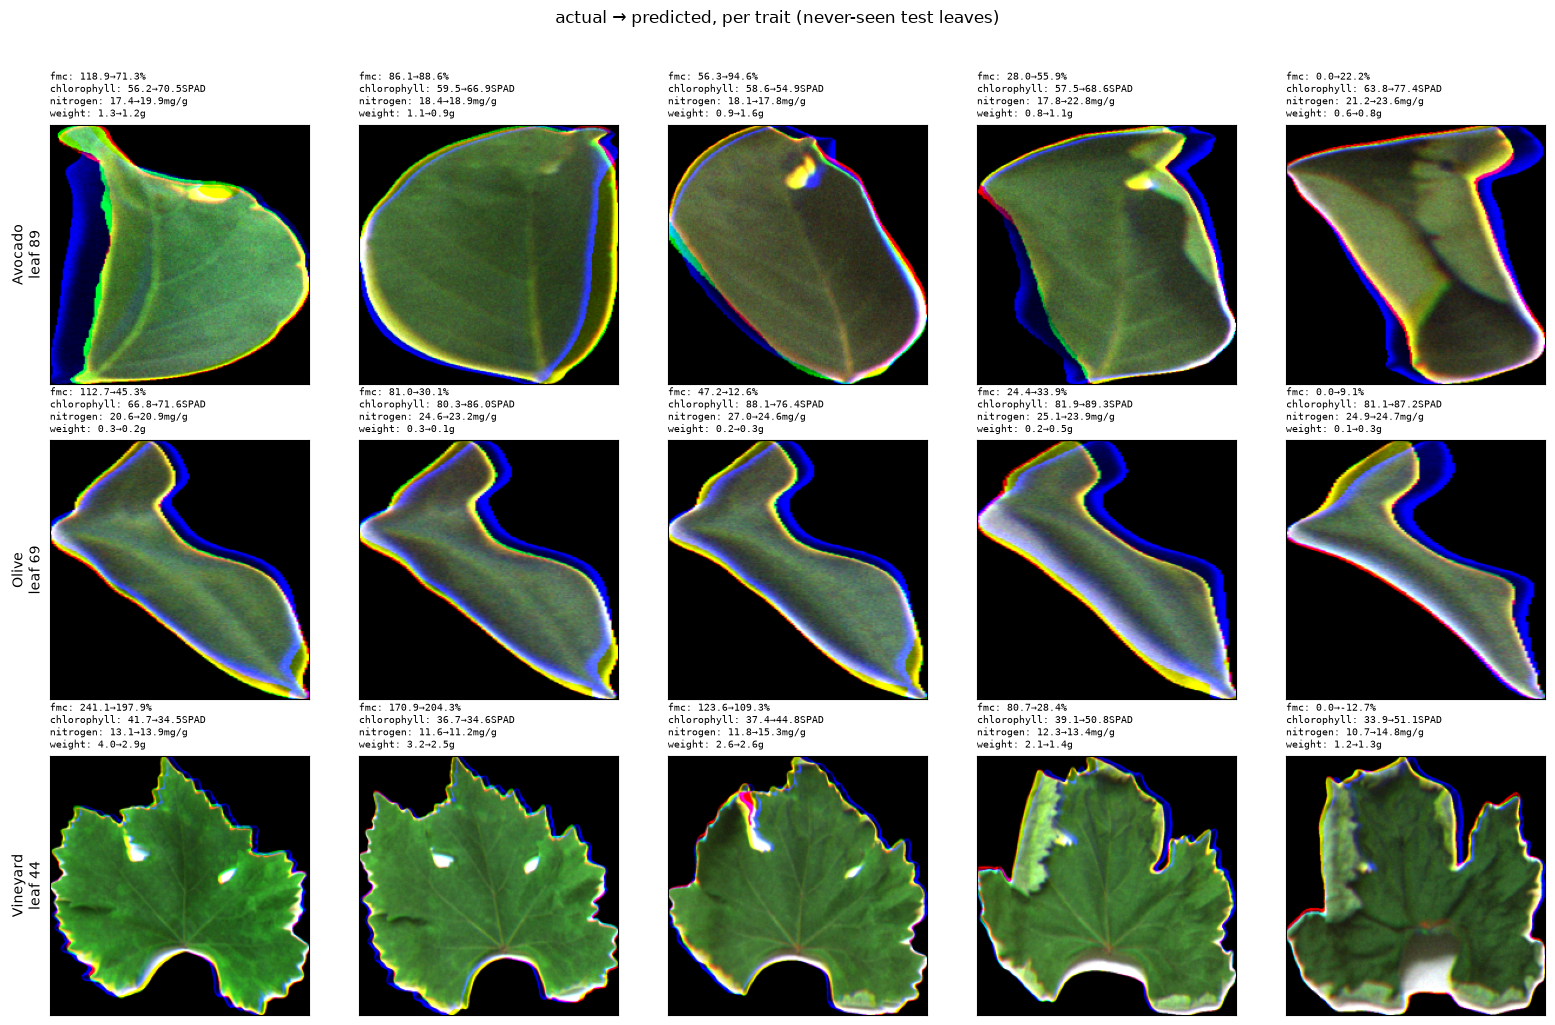

In [5]:
def load_rgb_preview(band_paths: list[Path], size: int = 220) -> np.ndarray:
    r = np.array(Image.open(band_paths[2]).resize((size, size), Image.BILINEAR), dtype=np.float32)
    g = np.array(Image.open(band_paths[1]).resize((size, size), Image.BILINEAR), dtype=np.float32)
    b = np.array(Image.open(band_paths[0]).resize((size, size), Image.BILINEAR), dtype=np.float32)
    rgb = np.stack([r, g, b], axis=-1)
    lo, hi = np.percentile(rgb, 2), np.percentile(rgb, 98)
    return np.clip((rgb - lo) / (hi - lo), 0, 1)


rng = np.random.default_rng(0)
test_idx_set = set(test_idx.tolist())

demo_leaf = {}
for sp in SPECIES:
    candidates = sorted({samples[i]["leaf"] for i in test_idx if samples[i]["species"] == sp})
    demo_leaf[sp] = int(rng.choice(candidates))

fig, axes = plt.subplots(len(SPECIES), 5, figsize=(16, 10))
for row, sp in enumerate(SPECIES):
    leaf = demo_leaf[sp]
    for stage in range(5):
        idx = next(i for i in test_idx
                   if samples[i]["species"] == sp and samples[i]["leaf"] == leaf and samples[i]["stage"] == stage)
        s = samples[idx]
        pos = test_idx_to_pos[idx]
        actual = y_test[pos]
        pred = test_preds[pos]

        ax = axes[row, stage]
        ax.imshow(load_rgb_preview(s["band_paths"]))
        ax.set_xticks([])
        ax.set_yticks([])

        lines = [f"{t}: {a:.1f}\u2192{p:.1f}{TRAIT_UNITS[t]}" for t, a, p in zip(TRAITS, actual, pred)]
        ax.set_title("\n".join(lines), fontsize=7, family="monospace", loc="left")

        if stage == 0:
            ax.set_ylabel(f"{sp}\nleaf {leaf}", fontsize=10)
        if row == 0:
            ax.set_xlabel("")

fig.suptitle("actual \u2192 predicted, per trait (never-seen test leaves)", y=1.02)
fig.tight_layout()
plt.show()